## Classification

### Generative vs Discriminate

* If we find ourselves asking which category is most likely to generate the observed result, then we are using using **density estimation** for classification and this is referred to as **generative classification**. Here we have a full model of the density for each class or we have a model which describes how data could be generated from each class. I want the pdf. GMM is a form of generative classification.

* But if we don't care about the full distribution, then we are doing something more like **clustering**, where we don't need to map the distribution, we just need to **define boundaries**. Classification that finds the decision boundary that separates classes is called **discriminative classification**. For high-dimensional data, this may be a better choice. I don't need pdf.

### Assesing results

Note that you choose the completeness and efficiency that you want by choosing a threshold (decision boundary).\
 The curves show you what your possible choices are (depending on where you set the threshold).

* **Roc Curve** true postive vs false positive. The threshold has to be decided to maximize the first and minimize the second. Equivalently plot **completeness versus efficiency (1 - contamination)**.

## Generative Classification

The goal is to predict the probability of data to belong to a given label p(x|y=y_k class conditioned density). It's a **density estimation** in the sense that we want to find the density region of points belonging to a certain class (from training set).\
Once the algorthm is trained we can associate a probability of a new point to belong to a given class, which is basically a **regression**.\
We call the decision boundary the probability of a new point to be (for example) equal for each class.\
Different algorithms depend on the assumptions on the priors.
 

### Naive Bayes

Assume no correlation between classes. Do it only for data with features expected to be indipendent.\
From there the process is just estimating densities: $p(x|y = y_k)$ and $p(y = y_k)$ are learned from a set of training data, where:

* **$p(y = y_k)$ is just the frequency of the class $k$**
* **$p(x|y = y_k)$ is just the density (probability) of an object with class $y_k$ having the attributes $x$**

An example is **Gaussian Naive** where all p(x|y=y_k) are all indipendent gaussian. Example with RR Lyrae. The algorithm is too simple, adding features like the number of filters can plot contamination and completness. adding feature the contamination stay costant, need a more complex algorithm.

Now we can drop uncorrelation assumption and build new classifiers.

#### Linear & Quadratic Discriminant Analysis

Now assume correlation between fearures.

* **LDA** use gaussian that include possible correlation between features and expand linearly with respect to mean of the class (it reduce a lot computational cost).
* **QDE** same but expand quadratically

The Bayes classifier is, therefore, linear with respect to X, and **discriminant boundary** between classes is the line that minimizes the overlap between Gaussians.

### GMM and Bayes Classifier

Substitute each pointlike density estimator with a GMM (gaussian mixture model) instead of a single gaussian with given mu and sigma.

**NOTE**: We can take this to the extreme by having one mixture component at each training point. We also don't have to restrict ourselves to a Gaussian kernel, we can use **any kernel** that we like. The resulting **non-parametric Bayes classifier** is referred to as **Kernel Discriminant Analysis** (KDA).


### K-nearest Neighbor Classifier

Based on the notion of distance, to be decided, and the number of K vicini to be considered. Preprocessing is essential. Nonparametric.

* If we did KDA with a variable bandwidth that depended only on the distance of the nearest neighbor, then we'd have what we call a **Nearest-Neighbor** classifier. Here if $x$ is close to $x'$, then $p(y|x) \approx p(y|x')$, i.e. **we use the class label of the nearest point**. Note that we have not assumed anything about the conditional density distribution, so it is completely non-parametric.

* What are we really cross validating for?
K and type of distances have to be cross-validate. In particular we cross validate one hyperparamter es K with respect to a given notion of distance or completness or accuracy and so on.


# SDSS Galaxies vs quasars


**Oggetti di Sklearn.Metrics usati**
* **roc_curve**: Calcola i vettori di FPR, TPR (Completeness) e le relative soglie di probabilità variando il punto di cut-off decisionale.
* **auc**: Calcola l'Area Sotto la Curva ROC. Fornisce un valore unico tra 0.5 (casuale) e 1.0 (perfetto) per quantificare il potere discriminante globale del modello.
* **precision_recall_curve**: Restituisce i valori di Precision e Recall per ogni soglia. Viene usata per mappare l'andamento continuo di Completeness (Recall) e Contamination (1 - Precision).
* **recall_score / precision_score**: Calcolano il valore puntuale di Completeness e Precision basandosi su predizioni binarie fisse \ (es. soglia di default a $p = 0.5$).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, precision_recall_curve, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from astroML.classification import GMMBayes

# colors
df = pd.read_csv('galaxyquasar.csv')
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

# galaxy=0, qso=1
df['label'] = np.where(df['class'] == 'QSO', 1, 0)

# define what feature i want to use
feature_sets = {
    '1 Colors: (g-r)': ['g_r'], 
    '2 Colors: (g-r, r-i)': ['g_r', 'r_i'],
    '3 Colors: (g-r, r-i, u-g)': ['g_r', 'r_i', 'u_g'],
    '4 Colors: (g-r, r-i, u-g, i-z)': ['g_r', 'r_i', 'u_g', 'i_z']
}

#dataset splitting, stratify manitene le proporzioni di size del sample splitting
df_train, df_val = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

y_train = df_train['label'].values
y_val = df_val['label'].values


## Gaussian Naive Bayes

Performance analysis of GNB using different number of features (colors) with ROC curve. 

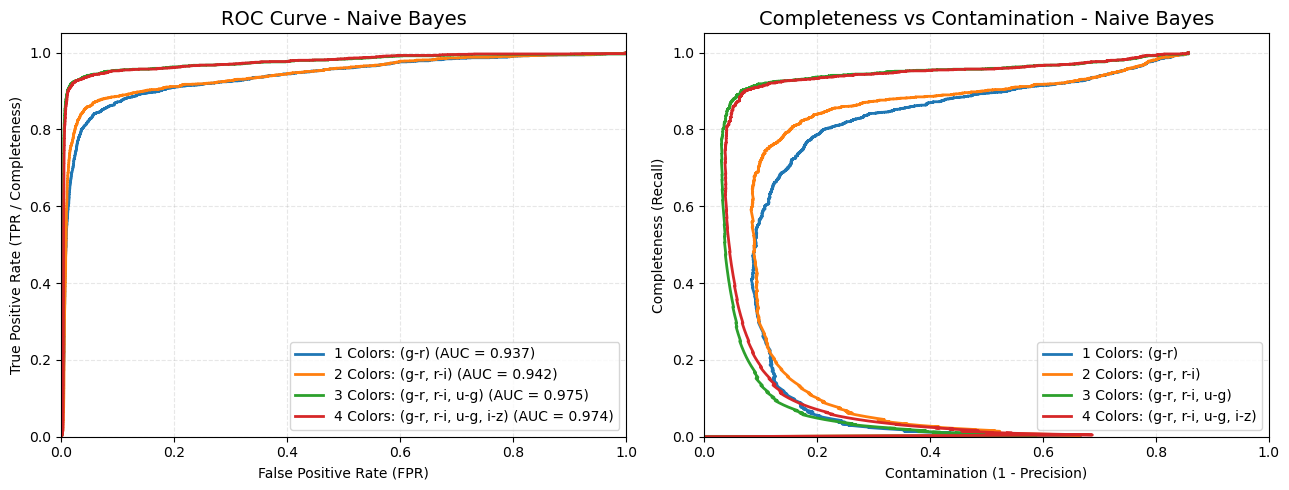

In [2]:
fig, (ax_roc, ax_comp) = plt.subplots(1, 2, figsize=(13,5))
model = GaussianNB()

for set_name, features in feature_sets.items():

    X_train = df_train[features].values
    X_val = df_val[features].values
    
    #train model on test data
    pipe = make_pipeline(StandardScaler(), model)
    pipe.fit(X_train, y_train)
    
    # probaility of val data to be a quasar
    y_prob = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    #print(len(tpr))
    #roc_curve decide lenght of fpr and tpr. ordina le y_prob, scarta doppioni, sceglie numero di soglie
    roc_auc = auc(fpr, tpr)     #area sottesa da roc
    ax_roc.plot(fpr, tpr, lw=2, label=f'{set_name} (AUC = {roc_auc:.3f})')
    
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    completeness = recall
    contamination = 1 - precision
    ax_comp.plot(contamination, completeness, lw=2, label=f'{set_name}')

ax_roc.set_title("ROC Curve - Naive Bayes", fontsize=14)
ax_roc.set_xlabel("False Positive Rate (FPR)")
ax_roc.set_ylabel("True Positive Rate (TPR / Completeness)")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_comp.set_title("Completeness vs Contamination - Naive Bayes", fontsize=14)
ax_comp.set_xlabel("Contamination (1 - Precision)")
ax_comp.set_ylabel("Completeness (Recall)")
ax_comp.legend(loc="lower right")
ax_comp.grid(alpha=0.3, linestyle='--')
ax_comp.set_xlim([0.0, 1.0])
ax_comp.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Highlightin the quality of the classification depending on the decision boundary

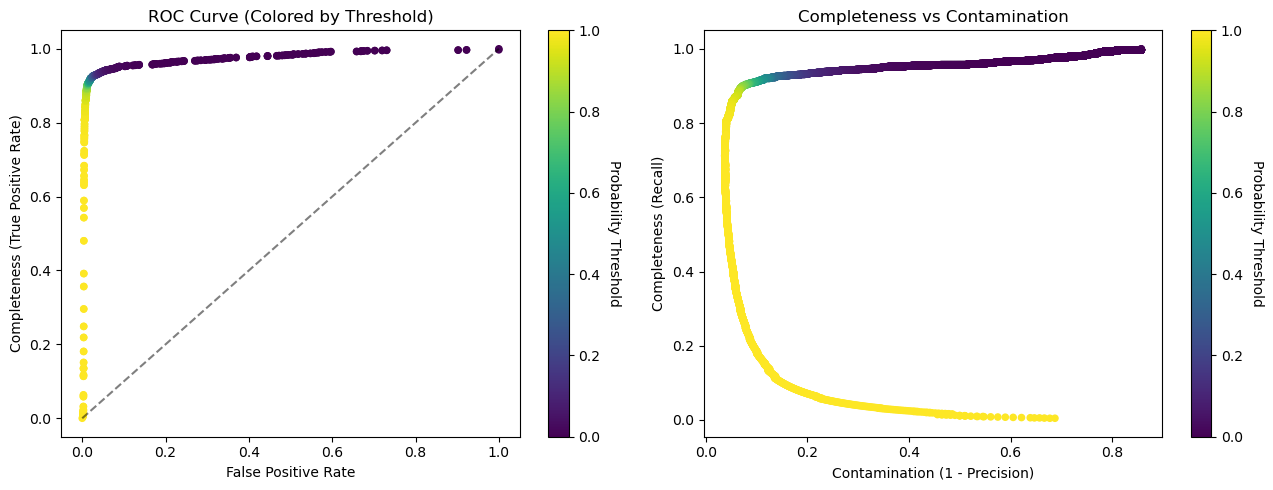

In [3]:
features = ['g_r', 'r_i', 'u_g', 'i_z']
X_train, X_val = df_train[features].values, df_val[features].values

pipe = make_pipeline(StandardScaler(), GaussianNB())
pipe.fit(X_train, y_train)
y_prob = pipe.predict_proba(X_val)[:, 1]

fig, (ax_roc, ax_comp) = plt.subplots(1, 2, figsize=(13, 5))
# estraggo i threshold per evidenziare la dipendenza della curva
fpr, tpr, thresholds_roc = roc_curve(y_val, y_prob)

thresholds_roc = np.clip(thresholds_roc, 0.0, 1.0)
#ax_roc.plot(fpr, tpr, color='gray', alpha=0.3)
sc_roc = ax_roc.scatter(fpr, tpr, c=thresholds_roc, cmap='viridis', s=20)
cbar_roc = plt.colorbar(sc_roc, ax=ax_roc)
cbar_roc.set_label('Probability Threshold', rotation=270, labelpad=15)

precision, recall, thresholds_pr = precision_recall_curve(y_val, y_prob)
# precision e recall hanno lunghezza N, ma thresholds_pr ha lunghezza N-1.
contamination = 1 - precision[:-1]
completeness = recall[:-1]
#ax_comp.plot(contamination, completeness, color='gray', alpha=0.3)
sc_comp = ax_comp.scatter(contamination, completeness, c=thresholds_pr, cmap='viridis', s=20)

cbar_comp = plt.colorbar(sc_comp, ax=ax_comp)
cbar_comp.set_label('Probability Threshold', rotation=270, labelpad=15)

ax_roc.set_title("ROC Curve (Colored by Threshold)", fontsize=12)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("Completeness (True Positive Rate)")
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)

ax_comp.set_title("Completeness vs Contamination", fontsize=12)
ax_comp.set_xlabel("Contamination (1 - Precision)")
ax_comp.set_ylabel("Completeness (Recall)")

plt.tight_layout()
plt.show()

**Analisi**: Per disegnare la ROC è necessario usare roc curve che prende y_prob in modo da mappare l'evoluzione della completness e del FPR al variare della soglia di classificazione scelta. In questo caso si osserva che per una threshold non inferiore a 0.7 la completness raggiunge quasi lo 0.9 mentre FPR resta a 0. Appena la soglia scende FPR cresce enormemente mentre la completness cresce pochissimo. 

**Conclusione**: Applicando una soglia di probabilità di 0.8, otteniamo un catalogo di quasar puro al 100% (zero contaminazione da galassie), riuscendo a recuperare l'85% di tutti i quasar presenti nel dataset (completness = 0.85).

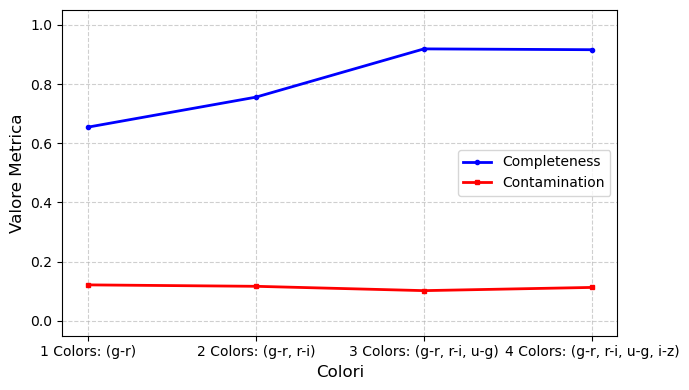

In [4]:
num_features, completeness_vals, contamination_vals, labels_x = [1,2,3,4], [], [], []
model = GaussianNB()

for label, features in feature_sets.items():
    X_train = df_train[features].values
    X_val = df_val[features].values
    
    pipe = make_pipeline(StandardScaler(), model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    
    completeness = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    contamination = 1 - precision
    
    completeness_vals.append(completeness)
    contamination_vals.append(contamination)
    labels_x.append(label)

plt.figure(figsize=(7, 4))
plt.plot(num_features, completeness_vals, 'o-', color='blue', markersize=3, lw=2, label='Completeness')
plt.plot(num_features, contamination_vals, 's-', color='red', markersize=3, lw=2, label='Contamination')
plt.xlabel("Colori", fontsize=12)
plt.ylabel("Valore Metrica", fontsize=12)
plt.ylim([-0.05, 1.05])
plt.xticks(num_features, labels_x)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

In [5]:
print(completeness_vals[-1],contamination_vals[-1])

0.9158878504672897 0.1131221719457014


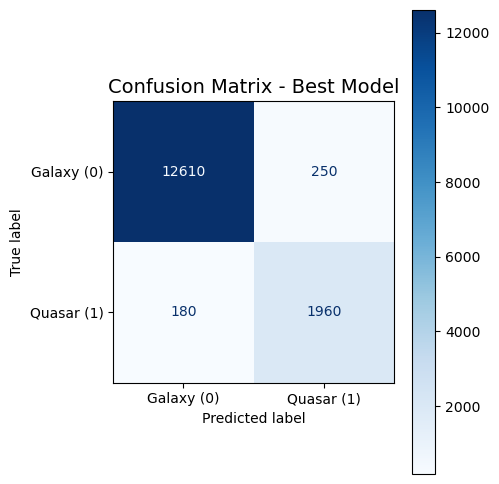

In [6]:
best_model = pipe.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)
cm = confusion_matrix(df_val['label'].values, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Galaxy (0)', 'Quasar (1)'])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - Best Model", fontsize=14)
plt.tight_layout()
plt.show()

## GMMBayes

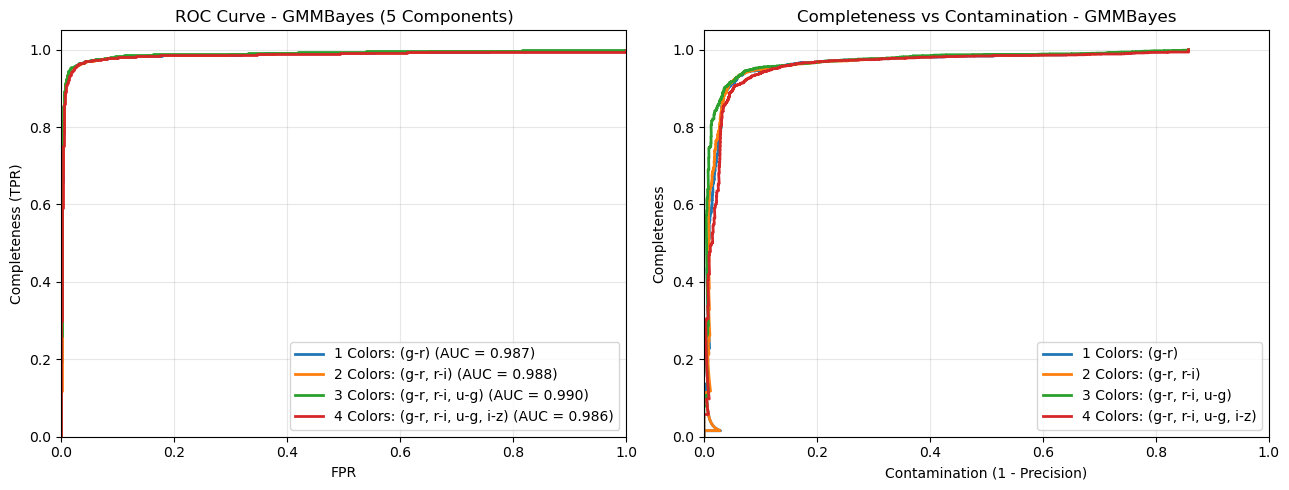

In [7]:
fig, (ax_roc, ax_comp) = plt.subplots(1, 2, figsize=(13, 5))
model5 = GMMBayes(n_components=5)

for set_name, features in feature_sets.items():

    pipe_GMM = make_pipeline(StandardScaler(), model5)
    pipe_GMM.fit(X_train, y_train)
    y_prob = pipe_GMM.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{set_name} (AUC = {auc(fpr, tpr):.3f})')
    
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    ax_comp.plot(1 - precision, recall, lw=2, label=f'{set_name}')


ax_roc.set(title="ROC Curve - GMMBayes (5 Components)", xlabel="FPR", ylabel="Completeness (TPR)", xlim=[0,1], ylim=[0,1.05])
ax_roc.legend(loc="lower right"); ax_roc.grid(alpha=0.3)
ax_comp.set(title="Completeness vs Contamination - GMMBayes", xlabel="Contamination (1 - Precision)", ylabel="Completeness", xlim=[0,1], ylim=[0,1.05])
ax_comp.legend(loc="lower right"); ax_comp.grid(alpha=0.3)
plt.tight_layout()
plt.show()

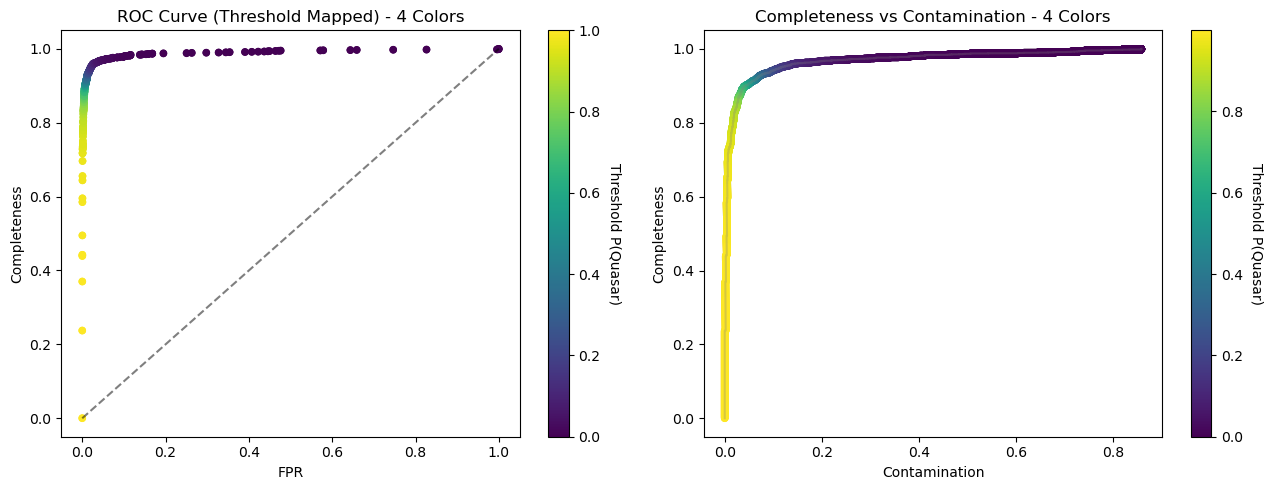

In [8]:
features = ['g_r', 'r_i', 'u_g', 'i_z']
X_train_4 = df_train[features].values
X_val_4 = df_val[features].values
y_train = df_train['label'].values
y_val = df_val['label'].values

pipe_GMM.fit(X_train_4, y_train)
y_prob_4 = pipe_GMM.predict_proba(X_val_4)[:, 1]

fig, (ax_roc, ax_comp) = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, thresholds_roc = roc_curve(y_val, y_prob_4)
sc_roc = ax_roc.scatter(fpr, tpr, c=np.clip(thresholds_roc, 0.0, 1.0), cmap='viridis', s=20)

plt.colorbar(sc_roc, ax=ax_roc).set_label('Threshold P(Quasar)', rotation=270, labelpad=15)
ax_roc.set(title="ROC Curve (Threshold Mapped) - 4 Colors", xlabel="FPR", ylabel="Completeness")
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)

precision, recall, thresholds_pr = precision_recall_curve(y_val, y_prob_4)
contamination = 1 - precision[:-1]
completeness = recall[:-1]

ax_comp.plot(contamination, completeness, color='gray', alpha=0.3)
sc_comp = ax_comp.scatter(contamination, completeness, c=thresholds_pr, cmap='viridis', s=20)

plt.colorbar(sc_comp, ax=ax_comp).set_label('Threshold P(Quasar)', rotation=270, labelpad=15)
ax_comp.set(title="Completeness vs Contamination - 4 Colors", xlabel="Contamination", ylabel="Completeness")
plt.tight_layout()
plt.show()

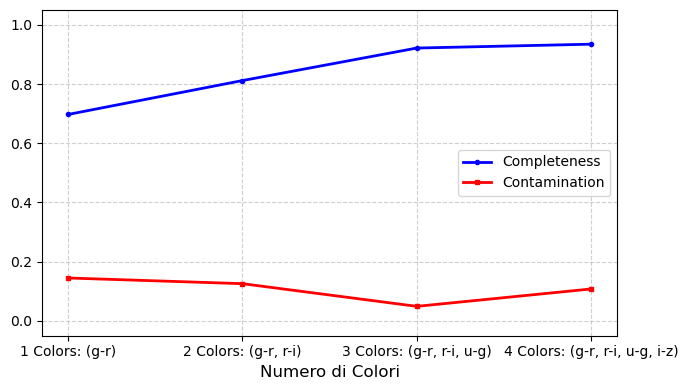

In [9]:
num_features, completeness_vals, contamination_vals, labels_x = [1,2,3,4], [], [], []

for set_name, features in feature_sets.items():

    pipe_GMM.fit(df_train[features].values, y_train)
    y_pred = pipe_GMM.predict(df_val[features].values)

    completeness_vals.append(recall_score(y_val, y_pred))
    contamination_vals.append(1 - precision_score(y_val, y_pred))
    labels_x.append(set_name)

plt.figure(figsize=(7, 4))
plt.plot(num_features, completeness_vals, 'o-', color='blue', markersize=3, lw=2, label='Completeness')
plt.plot(num_features, contamination_vals, 's-', color='red', markersize=3, lw=2, label='Contamination')
plt.xlabel("Numero di Colori", fontsize=12)
plt.xticks(num_features, labels_x)
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

In [10]:
print(completeness_vals[-1],contamination_vals[-1])

0.9345794392523364 0.1079393398751115


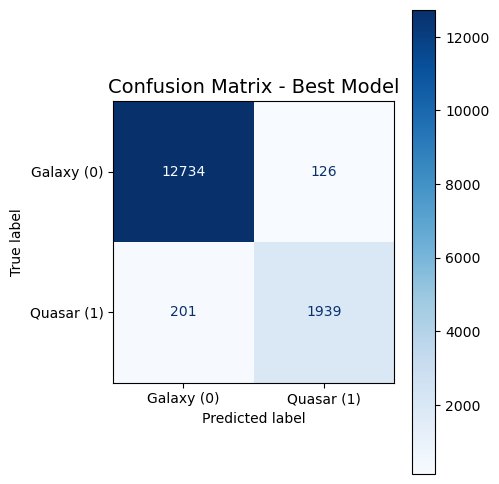

In [11]:
best_model = pipe_GMM.fit(X_train_4, y_train)
y_pred_best = best_model.predict(X_val_4)
cm = confusion_matrix(df_val['label'].values, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Galaxy (0)', 'Quasar (1)'])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap='Blues', ax=ax)

plt.title("Confusion Matrix - Best Model", fontsize=14)
plt.tight_layout()
plt.show()

## K-nearest

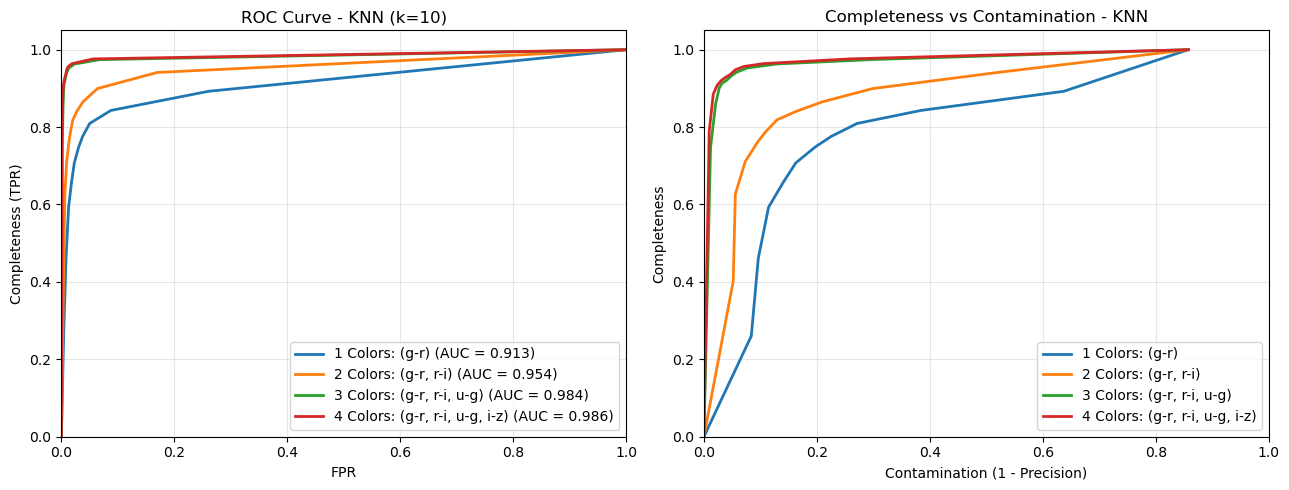

In [12]:
fig, (ax_roc, ax_comp) = plt.subplots(1, 2, figsize=(13, 5))
modelK = KNeighborsClassifier(n_neighbors=10)

for set_name, features in feature_sets.items():

    pipe_knn = make_pipeline(StandardScaler(), modelK)
    pipe_knn.fit(df_train[features].values, y_train)

    y_prob_knn = pipe_knn.predict_proba(df_val[features].values)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob_knn)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{set_name} (AUC = {auc(fpr, tpr):.3f})')
    
    precision, recall, _ = precision_recall_curve(y_val, y_prob_knn)
    ax_comp.plot(1 - precision, recall, lw=2, label=f'{set_name}')

ax_roc.set(title="ROC Curve - KNN (k=10)", xlabel="FPR", ylabel="Completeness (TPR)", xlim=[0,1], ylim=[0,1.05])
ax_roc.legend(loc="lower right"); ax_roc.grid(alpha=0.3)

ax_comp.set(title="Completeness vs Contamination - KNN", xlabel="Contamination (1 - Precision)", ylabel="Completeness", xlim=[0,1], ylim=[0,1.05])
ax_comp.legend(loc="lower right"); ax_comp.grid(alpha=0.3)
plt.tight_layout()
plt.show()

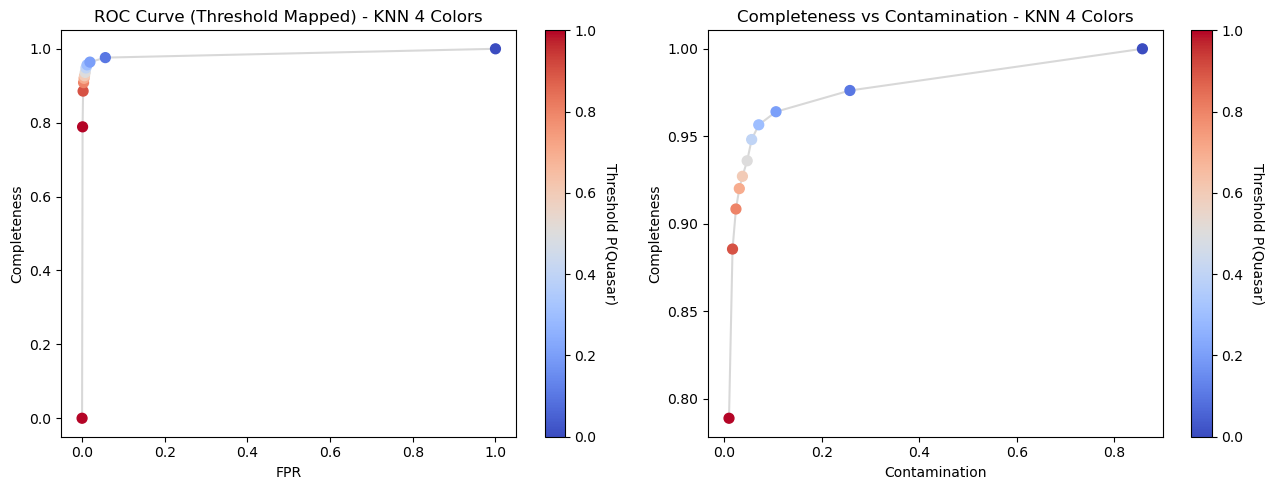

In [13]:
# la threshold per questo algoritm può assumere solo valori discreti
pipe_knn.fit(X_train_4, y_train)
y_prob_knn_4 = pipe_knn.predict_proba(X_val_4)[:, 1]
fig, (ax_roc, ax_comp) = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, thresholds_roc = roc_curve(y_val, y_prob_knn_4)
ax_roc.plot(fpr, tpr, color='gray', alpha=0.3) 
sc_roc = ax_roc.scatter(fpr, tpr, c=np.clip(thresholds_roc, 0.0, 1.0), cmap='coolwarm', s=50, zorder=5)

plt.colorbar(sc_roc, ax=ax_roc).set_label('Threshold P(Quasar)', rotation=270, labelpad=15)
ax_roc.set(title="ROC Curve (Threshold Mapped) - KNN 4 Colors", xlabel="FPR", ylabel="Completeness")
#ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)

# Completness/Comntamination
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_prob_knn_4)
contamination = 1 - precision[:-1]
completeness = recall[:-1]

ax_comp.plot(contamination, completeness, color='gray', alpha=0.3)
sc_comp = ax_comp.scatter(contamination, completeness, c=thresholds_pr, cmap='coolwarm', s=50, zorder=5)

plt.colorbar(sc_comp, ax=ax_comp).set_label('Threshold P(Quasar)', rotation=270, labelpad=15)
ax_comp.set(title="Completeness vs Contamination - KNN 4 Colors", xlabel="Contamination", ylabel="Completeness")
#ax_comp.invert_xaxis()

plt.tight_layout()
plt.show()

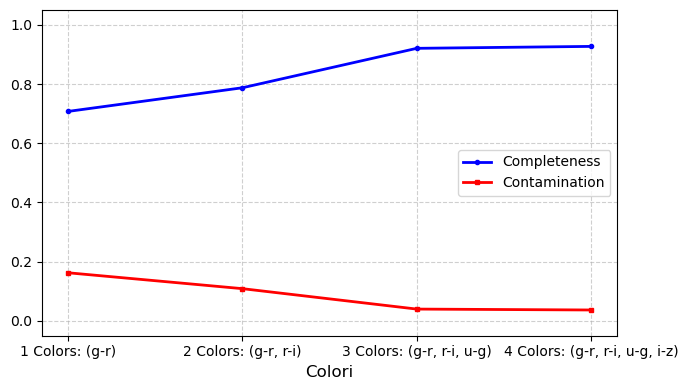

In [14]:
num_features, completeness_vals, contamination_vals, labels_x = [1,2,3,4], [], [], []

for set_name, features in feature_sets.items():
    
    pipe_knn.fit(df_train[features].values, y_train)
    y_pred_knn = pipe_knn.predict(df_val[features].values) # Applica soglia p=0.5

    completeness_vals.append(recall_score(y_val, y_pred_knn))
    contamination_vals.append(1 - precision_score(y_val, y_pred_knn))
    labels_x.append(set_name)

plt.figure(figsize=(7, 4))
plt.plot(num_features, completeness_vals, 'o-', color='blue', markersize=3, lw=2, label='Completeness')
plt.plot(num_features, contamination_vals, 's-', color='red', markersize=3, lw=2, label='Contamination')

plt.xlabel("Colori", fontsize=12)
plt.xticks(num_features, labels_x)
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

In [15]:
print(completeness_vals[-1],contamination_vals[-1])

0.9271028037383178 0.03689320388349515


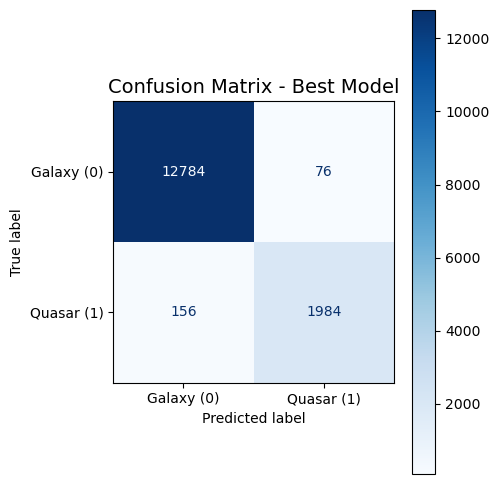

In [16]:
best_model = pipe_knn.fit(X_train_4, y_train)
y_pred_best = best_model.predict(X_val_4)
cm = confusion_matrix(df_val['label'].values, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Galaxy (0)', 'Quasar (1)'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax)

plt.title("Confusion Matrix - Best Model", fontsize=14)
plt.tight_layout()
plt.show()

### Costi e Score

* Analisi del costo computazionale (si divide in costo train e predict): naive e gmm buoni, knear disastro a causa calcolo distanze
* Score per cross validare: dipende dal problema, due metriche interessanti sono F1score (bilancia completness e contamination) e AUC-PR (area sottesa non dalla ROC ma dalla precision recall)